# Inclination-shallowing corrections

Detrital remanent magnetization in sedimentary rocks is commonly shallower than the field in which it was acquired, as a result of processes during deposition and compaction (King, 1955; Tauxe & Kent, 2004). A pole calculated from shallowed directions is displaced away from the sampling locality along the great circle that joins them, so the paleolatitude it implies is too close to the equator. The degree of shallowing is described by the flattening factor $f$ (King, 1955):

$$\tan I_o = f \, \tan I_f$$

where $I_o$ is the observed inclination and $I_f$ is the inclination of the ambient field.

Sedimentary poles in this compilation are reported as measured in the [main pole table](compilation.md), and corrected for inclination shallowing in the separate [table of corrected poles](compilation.md#inclination-shallowing-corrections). The corrected positions are what the APWP and paleolatitude figures plot for these units. Following Pierce et al. (2022), each corrected pole is the mean of a Kent (1982) distribution fit to a large population of resampled mean poles, so that its elliptical 95% confidence region carries the uncertainty in $f$ together with the uncertainty in the pole itself. The value of $f$ comes from one of two sources:

1. **The unit's own directions.** Where a unit has a large population of independent directions, $f$ is determined from the shape of the directional distribution, using either the elongation/inclination (E/I) method of Tauxe & Kent (2004) or the SVEI method of Tauxe et al. (2024). Both find the $f$ for which the unflattened directions are consistent with the distribution predicted by a statistical paleosecular variation model: TK03.GAD for E/I, and THG24 for SVEI.
2. **A compilation.** Where only a mean pole, or too few directions for E/I or SVEI, are available, $f$ is resampled from the compilation of $f$ values that Pierce et al. (2022) assembled from sedimentary units with independent determinations.

Both routes are implemented in PmagPy (Tauxe et al., 2016), as `ipmag.find_ei_kent`, `ipmag.find_svei_kent`, and `ipmag.find_compilation_kent`. This page works through one unit from the compilation by each route. It documents what was done in this study, and it can serve as a template for applying the same approach to other sedimentary poles.

:::{note} PmagPy version
This page uses PmagPy from its [GitHub master branch](https://github.com/PmagPy/PmagPy). `ipmag.PIERCE2022_F_COMPILATION`, and a correction to `ipmag.find_compilation_kent` (which previously used only the first 70 of its `n` resampled $f$ values), are newer than the 4.5.2 release. Until they are in a tagged release, install with `pip install git+https://github.com/PmagPy/PmagPy.git`.
:::

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag

%matplotlib inline

/Users/unimos/miniforge3/envs/pmagpy-dev/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## The flattening factor

The effect of a given $f$ depends on the inclination (panel a). Shallowing goes to zero at the equator and at the poles, and it is greatest at intermediate inclinations. As a result, the same correction barely moves a pole from a unit that was deposited near the equator (such as the Uinta Mountain Group or the lower Freda Formation), but it can shift a pole from a mid-latitude unit by more than 10°.

Panel b shows the 70 values of $f$ compiled by Pierce et al. (2022), which PmagPy provides as `ipmag.PIERCE2022_F_COMPILATION`. These are the values that the compilation route resamples. Their median and central 95% range are the $f$ and bounds listed for compilation-corrected poles in the table of corrected poles.

Pierce et al. (2022) compilation: n = 70, median f = 0.62, 95% range 0.43-0.91


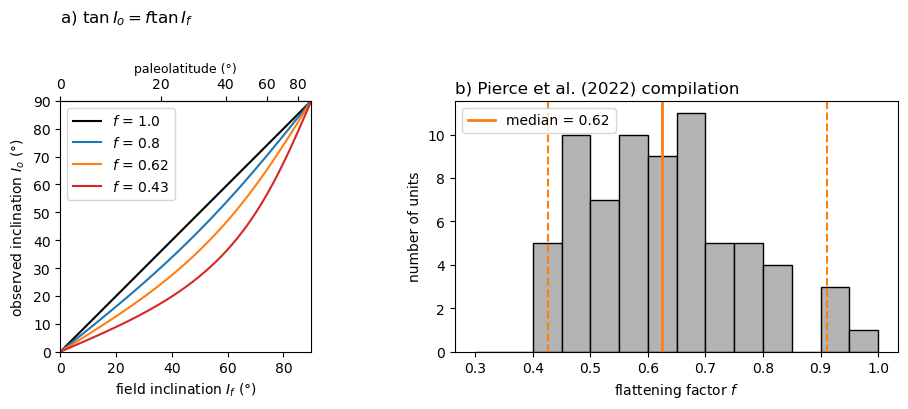

In [2]:
f_compilation = np.array(ipmag.PIERCE2022_F_COMPILATION)
f_median = np.median(f_compilation)
f_low, f_high = np.percentile(f_compilation, [2.5, 97.5])
print(f'Pierce et al. (2022) compilation: n = {len(f_compilation)}, '
      f'median f = {f_median:.2f}, 95% range {f_low:.2f}-{f_high:.2f}')

fig, (ax_inc, ax_hist) = plt.subplots(1, 2, figsize=(10, 4.2))

inc_field = np.linspace(0, 90, 181)
for f, color in zip([1.0, 0.8, 0.62, 0.43], ['k', 'C0', 'C1', 'C3']):
    ax_inc.plot(inc_field, ipmag.squish(inc_field, f), color=color, label=f'$f$ = {f}')
paleolat_ticks = np.array([0, 10, 20, 30, 45, 60, 90])
ax_inc.set_xlabel('field inclination $I_f$ (°)')
ax_inc.set_ylabel('observed inclination $I_o$ (°)')
ax_inc.set_xlim(0, 90)
ax_inc.set_ylim(0, 90)
ax_inc.set_aspect('equal')
ax_inc.legend(loc='upper left')
ax_inc.set_title('a) $\\tan I_o = f \\tan I_f$', loc='left', pad=28)
ax_top = ax_inc.secondary_xaxis('top', functions=(
    lambda inc: np.degrees(np.arctan(np.tan(np.radians(np.clip(inc, 0, 89.9))) / 2)),
    lambda lat: np.degrees(np.arctan(2 * np.tan(np.radians(np.clip(lat, 0, 89.9)))))))
ax_top.set_xlabel('paleolatitude (°)', fontsize=9)

ax_hist.hist(f_compilation, bins=np.arange(0.3, 1.05, 0.05), color='0.7', edgecolor='k')
ax_hist.axvline(f_median, color='C1', lw=2, label=f'median = {f_median:.2f}')
for bound in (f_low, f_high):
    ax_hist.axvline(bound, color='C1', ls='--')
ax_hist.set_xlabel('flattening factor $f$')
ax_hist.set_ylabel('number of units')
ax_hist.legend(loc='upper left')
ax_hist.set_title('b) Pierce et al. (2022) compilation', loc='left')

plt.tight_layout()
plt.show()

## Case study 1: $f$ from the data (E/I, Nonesuch Formation)

The [Nonesuch Formation](pole_notebooks/1078_Nonesuch.ipynb) pole of Slotznick et al. (2024) is based on 182 tilt-corrected directions (105 detrital hematite and 77 detrital magnetite), from lacustrine and fluvial strata of the Potato River Falls section ([MagIC 20614](https://earthref.org/MagIC/20614)). Each direction comes from a single specimen at a distinct stratigraphic horizon, with samples spaced less than 0.5 m apart. As a result, the directions can be treated as independent spot readings of the field, and there are enough of them to resolve the elongation of the distribution, which is the condition that E/I requires.

We first calculate the pole as measured.

In [3]:
sites = pd.read_csv('data/1078_Nonesuch/sites.txt', sep='\t', skiprows=1)
drm = sites[sites['dir_comp_name'].isin(['hdt', 'mt']) &
            (sites['dir_tilt_correction'] == 100)]
nonesuch_di = ipmag.make_di_block(drm['dir_dec'].tolist(), drm['dir_inc'].tolist())
nonesuch_lat, nonesuch_lon = 46.5, -90.5   # Potato River Falls section

nonesuch_vgps = [pmag.dia_vgp(dec, inc, 0, nonesuch_lat, nonesuch_lon)[:2]
                 for dec, inc, _ in nonesuch_di]
nonesuch_pole = ipmag.fisher_mean([v[0] for v in nonesuch_vgps], [v[1] for v in nonesuch_vgps])
print(f'N = {len(nonesuch_di)} directions')
print(f"As-measured pole: {nonesuch_pole['inc']:.1f}°N, {nonesuch_pole['dec']:.1f}°E, "
      f"A95 = {nonesuch_pole['alpha95']:.1f}°")

N = 182 directions
As-measured pole: 3.9°N, 180.4°E, A95 = 1.7°


`ipmag.find_ei_kent` carries out the E/I analysis in three steps, and then propagates its result to the pole:

1. It finds the $f$ for which the elongation and inclination of the unflattened directions match the TK03.GAD prediction, and repeats this for `nb` bootstrap resamples of the directions. The figures that follow show the elongation–inclination curves of the data (red) and of the bootstrap resamples (grey), and the cumulative distribution of the corrected inclinations from the bootstrap.
2. For each bootstrapped $f$, it unflattens the directions and computes a mean VGP, from which it then draws `vgp_nb` Fisher-distributed mean poles. The figures that follow show the unflattened directions colored by $f$, and the implied paleolatitudes.
3. It fits a Kent distribution to the resulting `nb` × `vgp_nb` mean poles. The final map shows this distribution.

This run takes about a minute.

Bootstrapping.... be patient



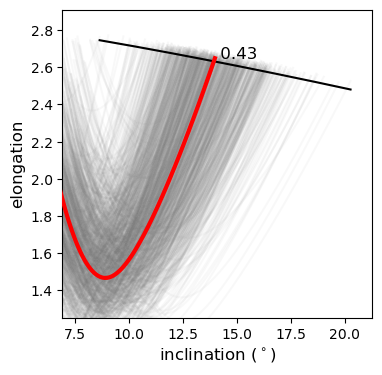

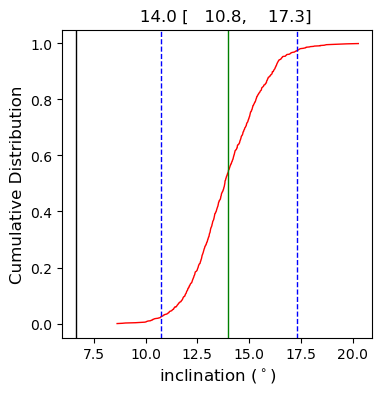

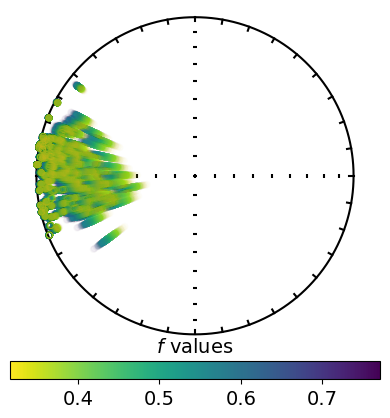

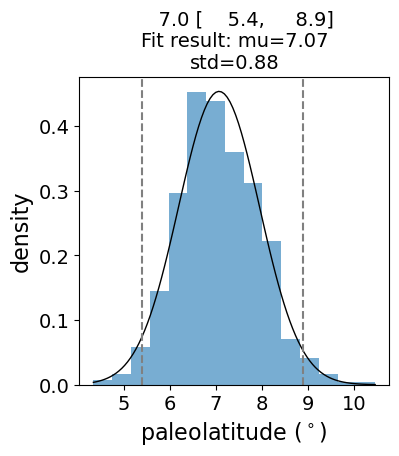

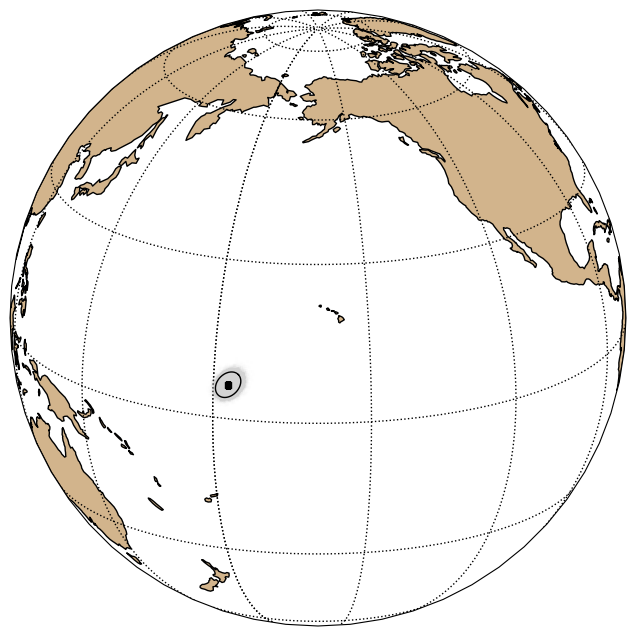

The original inclination was: 6.67

The corrected inclination is: 13.97
with bootstrapped confidence bounds of: 10.77 to 17.32
and elongation parameter of: 2.65
The flattening factor is: 0.43
with bootstrapped confidence bounds of: 0.62 to 0.38

The Kent mean incorporating inclination flattening uncertainty is:
Plon: 182.9  Plat: 6.6
Major axis lon: 280.1  Major axis lat: 47.3
Minor axis lon: 86.9  Minor axis lat: 41.9
Major axis angle of 95% ellipse (Zeta): 2.9
Minor axis angle of 95% ellipse (Eta): 2.0
Number of directions in mean (n): 100000


In [4]:
_, nonesuch_kent, I_boot, E_boot, f_boot = ipmag.find_ei_kent(
    nonesuch_di, site_latitude=nonesuch_lat, site_longitude=nonesuch_lon,
    nb=1000, vgp_nb=100, return_new_dirs=True, return_values=True,
    central_longitude=200, central_latitude=20, random_seed=23)
plt.show()

The E/I flattening factor of $f$ = 0.43 (bootstrap 95% bounds 0.38–0.62) reproduces the result of Slotznick et al. (2024), and it is lower than the median of the compilation. The correction moves the pole about 3° north, toward the sampling locality. The Kent ellipse that results is only moderately elongate ($\zeta_{95}$ ≈ 2.9°, $\eta_{95}$ ≈ 2.0°), because the large number of directions constrains $f$ tightly.

The cell below plots the uncorrected and corrected poles together.

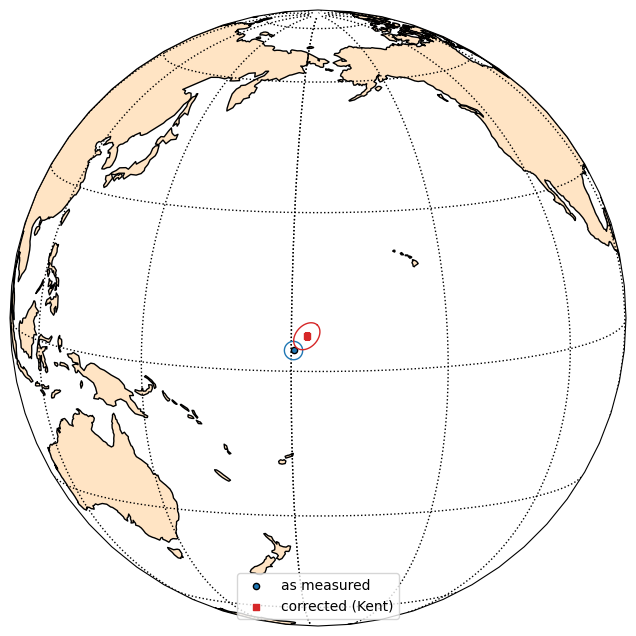

In [5]:
pole_map = ipmag.make_orthographic_map(185, 10, land_color='bisque')
ipmag.plot_pole(pole_map, nonesuch_pole['dec'], nonesuch_pole['inc'], nonesuch_pole['alpha95'],
                color='C0', marker='o', label='as measured')
ipmag.plot_pole_ellipse(pole_map, nonesuch_kent, color='C3', edgecolor='C3', label='corrected (Kent)')
plt.legend(loc='lower center')
plt.show()

## Case study 2: $f$ from the compilation (Chuar Group)

The combined [Chuar Group](pole_notebooks/755_Chuar_Group.ipynb) pole is the Fisher mean of 37 site and sample VGPs from three members, drawn from Weil et al. (2004) and Eyster et al. (2020). As measured, it is at 7.5°N, 163.6°E ($A_{95}$ = 4.2°). This pole has fewer directions than ideal for the application of statistical flattening correction approachs. Many sedimentary poles are in the same position particularly ones that were published only as mean poles.

`ipmag.find_compilation_kent` needs only the pole and the sampling locality:

1. It converts the pole into the mean direction it implies at the sampling locality.
2. It draws `n` values of $f$ from the compilation, and unflattens the mean inclination with each one.
3. It converts each unflattened direction back into a pole, around which it draws `n_fish` Fisher-distributed mean poles using the original $A_{95}$.
4. It fits a Kent distribution to the resulting `n` × `n_fish` mean poles.

We set `n = 10000`, to match the 1,000,000 resampled poles behind the compilation table. The figures that follow show the resampled $f$ values, the implied paleolatitudes, and a map of the resampled poles with the Kent ellipse and the as-measured pole. This run takes about a minute.

Plon: 168.3  Plat: 10.8
Major axis lon: 265.7  Major axis lat: 34.2
Minor axis lon: 63.3  Minor axis lat: 53.6
Major axis angle of 95% ellipse (Zeta): 8.2
Minor axis angle of 95% ellipse (Eta): 4.2
Number of directions in mean (n): 1000000


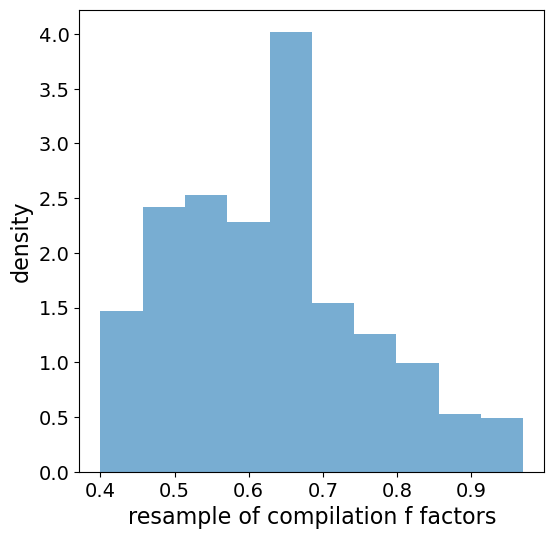

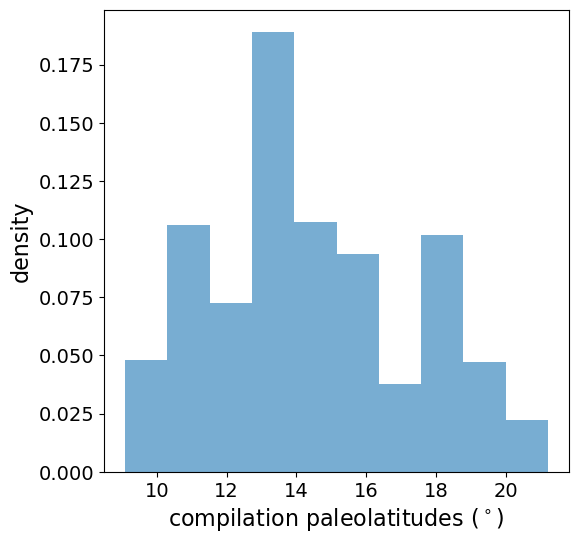

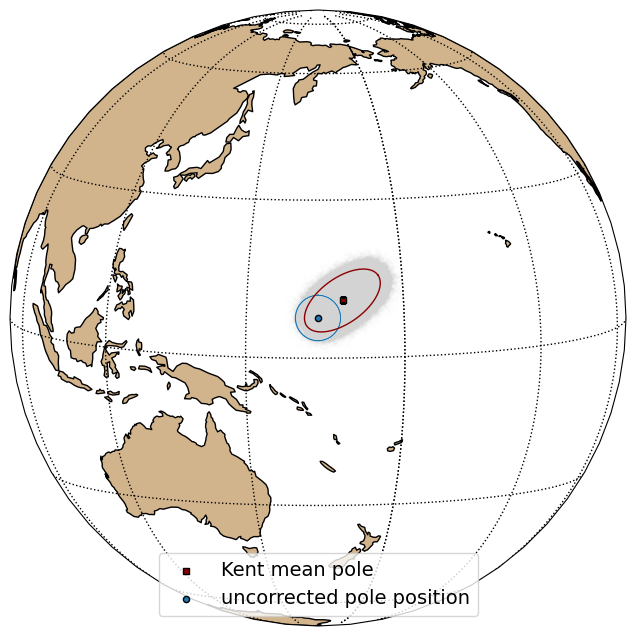

In [6]:
chuar_pole = {'dec': 163.6, 'inc': 7.5, 'alpha95': 4.2}   # as-measured pole (°E, °N, °)
chuar_lon, chuar_lat = 248.13, 36.23                        # sampling locality

chuar_kent = ipmag.find_compilation_kent(
    chuar_pole['dec'], chuar_pole['inc'], chuar_pole['alpha95'], chuar_lon, chuar_lat,
    n=10000, n_fish=100, random_seed=1,
    map_central_longitude=chuar_pole['dec'], map_central_latitude=chuar_pole['inc'])
plt.show()

The corrected pole (10.8°N, 168.3°E, within 0.1° of the tabulated value) moves toward the sampling locality, and its ellipse is strongly elongate along the great circle between the two ($\zeta_{95}$ ≈ 8.2°, compared with an as-measured $A_{95}$ of 4.2°). This elongation reflects the broad range of $f$ in the compilation (0.43–0.91), which is wider than the range a unit-specific determination typically gives (0.38–0.62 for the Nonesuch Formation). The larger uncertainty is the cost of not having an $f$ determination for the unit itself. For Chuar, and for the other compilation-corrected poles, new directional data that allow E/I or SVEI would be one route to a tighter constraint.

## A third option: SVEI

The SVEI method of Tauxe et al. (2024) also works from the directions themselves. It compares them with the THG24 paleosecular variation model, and returns the range of $f$ that is consistent with that model. `ipmag.find_svei_kent` then samples $f$ uniformly within that range, and propagates it to the pole in the same way as `find_ei_kent`. The [upper Freda Formation](pole_notebooks/1045_Upper_Freda.ipynb) pole in this compilation takes this route: its SVEI range of $f$ = 0.59–0.87 comes from Fuentes et al. (2025).

```python
from pmagpy import svei

# 1. The range of f consistent with the THG24 model (Tauxe et al., 2024).
flat_results = svei.find_flat(di_block, plot=True)

# 2. Propagate that range (f_low, f_high) to a Kent mean pole.
kent = ipmag.find_svei_kent(di_block, site_lat, site_lon, f_low=0.59, f_high=0.87,
                            n=1000, vgp_nb=100, random_seed=23)
```

## Corrections applied in this compilation

The table below summarizes the corrections applied to the 12 sedimentary poles in the compilation. `f low` and `f high` are the bootstrap bounds (for E/I), the SVEI range, or the central 95% of the compilation. Two units (the Jacobsville and Nonesuch formations) have $f$ from E/I, one (the upper Freda Formation) has $f$ from SVEI, and the remaining nine are corrected with the compilation. The paleolatitude of Duluth that each pole implies, before and after correction, is given in the [table of corrected poles](compilation.md#inclination-shallowing-corrections).

In [7]:
kent_poles = pd.read_csv('data/nordic_summaries/kent_poles_combined.csv', encoding='utf-8-sig')
kent_poles['f method'] = kent_poles['f method'].str.replace(r'\s*\(.*\)', '', regex=True)
kent_poles[['ROCKNAME', 'nominal age', 'f method', 'f', 'f low', 'f high',
            'PLAT uncorrected', 'PLONG uncorrected', 'A95 uncorrected',
            'PLAT', 'PLONG', 'Zeta', 'Eta']].rename(columns={
    'ROCKNAME': 'unit', 'nominal age': 'age (Ma)', 'PLAT uncorrected': 'plat meas.',
    'PLONG uncorrected': 'plon meas.', 'A95 uncorrected': 'A95 meas.',
    'PLAT': 'plat corr.', 'PLONG': 'plon corr.', 'Zeta': 'ζ95', 'Eta': 'η95'}
).set_index('unit')

,age (Ma),f method,f,f low,f high,plat meas.,plon meas.,A95 meas.,plat corr.,plon corr.,ζ95,η95
unit,,,,,,,,,,,,
Chuar Group (combined),755,compilation f,0.62,0.43,0.91,7.5,163.6,4.2,10.8,168.2,8.2,4.2
Uinta Mountain Group,759,compilation f,0.62,0.43,0.91,1.9,160.6,2.1,2.4,161.1,2.3,2.1
Torridon Group,975,compilation f,0.62,0.43,0.91,-17.7,220.9,7.1,-29.6,213.3,16.0,7.2
Jacobsville Formation,990,E/I,0.64,0.51,0.83,-14.2,186.2,2.7,-16.9,183.4,4.1,3.1
Upper Freda Formation,1045,SVEI,0.73,0.59,0.87,4.7,169.8,2.1,3.6,168.8,2.8,2.4
Lower Freda Formation,1075,compilation f,0.62,0.43,0.91,1.2,179.7,2.4,1.4,179.8,2.4,2.4
Nonesuch Formation,1077,E/I,0.43,0.38,0.62,3.9,180.4,1.7,6.6,182.9,2.8,2.0
Stoer Group,1199,compilation f,0.62,0.43,0.91,37.2,238.4,7.7,46.1,246.1,14.8,7.8
"Pilcher, Garnet Range, Libby",1385,compilation f,0.62,0.43,0.91,-20.6,217.6,7.9,-11.1,221.2,14.5,8.0


## Applying this approach to other poles

- **If you have many independent directions** (specimen- or sample-level directions, each an independent reading of the field, typically numbering in the hundreds), determine $f$ with E/I (`ipmag.find_ei_kent`) or SVEI (`svei.find_flat` followed by `ipmag.find_svei_kent`). Use tilt-corrected directions. Where several specimens come from the same horizon, they should not be treated as independent.
- **If you have only a mean pole, or too few directions,** use `ipmag.find_compilation_kent` with the pole longitude, latitude, $A_{95}$, and sampling locality. Through `f_from_compilation` you can supply a different compilation of $f$ values, for example one restricted to a particular lithology or remanence carrier.
- **Report both poles:** the as-measured pole, and the Kent mean with $\zeta_{95}$, $\eta_{95}$, the source of $f$, and its range. Fix `random_seed`, so that the reported Kent statistics can be reproduced.

## References

- Eyster, A., Weiss, B. P., Karlstrom, K., & Macdonald, F. A. (2020). Paleomagnetism of the Chuar Group and evaluation of the late Tonian Laurentian apparent polar wander path with implications for the makeup and breakup of Rodinia. *GSA Bulletin*, 132, 710–738. https://doi.org/10.1130/B32012.1
- Fuentes, A. J., Fairchild, L. M., Hodgin, E. B., Alemu, T., & Swanson-Hysell, N. L. (2025). Termination of Laurentia's rapid plate motion at the start of the Grenvillian Orogeny. *Journal of Geophysical Research: Solid Earth*, 130, e2025JB031794. https://doi.org/10.1029/2025JB031794
- Kent, J. T. (1982). The Fisher-Bingham distribution on the sphere. *Journal of the Royal Statistical Society: Series B*, 44, 71–80. https://doi.org/10.1111/j.2517-6161.1982.tb01189.x
- King, R. F. (1955). The remanent magnetism of artificially deposited sediments. *Geophysical Journal International*, 7, 115–134. https://doi.org/10.1111/j.1365-246X.1955.tb06558.x
- Pierce, J., Zhang, Y., Hodgin, E. B., & Swanson-Hysell, N. L. (2022). Quantifying inclination shallowing and representing flattening uncertainty in sedimentary paleomagnetic poles. *Geochemistry, Geophysics, Geosystems*, 23, e2022GC010682. https://doi.org/10.1029/2022GC010682
- Slotznick, S. P., Swanson-Hysell, N. L., Zhang, Y., Clayton, K. E., Wellman, C. H., Tosca, N. J., & Strother, P. K. (2024). Reconstructing the paleoenvironment of an oxygenated Mesoproterozoic shoreline and its record of life. *GSA Bulletin*, 136, 2842–2864. https://doi.org/10.1130/B36634.1
- Tauxe, L., & Kent, D. V. (2004). A simplified statistical model for the geomagnetic field and the detection of shallow bias in paleomagnetic inclinations: Was the ancient magnetic field dipolar? In *Timescales of the Paleomagnetic Field*, Geophysical Monograph 145, 101–115. https://doi.org/10.1029/145GM08
- Tauxe, L., Heslop, D., & Gilder, S. A. (2024). Assessing paleosecular variation averaging and correcting paleomagnetic inclination shallowing. *Journal of Geophysical Research: Solid Earth*, 129, e2024JB029502. https://doi.org/10.1029/2024JB029502
- Tauxe, L., Shaar, R., Jonestrask, L., Swanson-Hysell, N. L., Minnett, R., Koppers, A. A. P., Constable, C. G., Jarboe, N., Gaastra, K., & Fairchild, L. (2016). PmagPy: Software package for paleomagnetic data analysis and a bridge to the Magnetics Information Consortium (MagIC) Database. *Geochemistry, Geophysics, Geosystems*, 17, 2450–2463. https://doi.org/10.1002/2016GC006307
- Weil, A. B., Geissman, J. W., & Van der Voo, R. (2004). Paleomagnetism of the Neoproterozoic Chuar Group, Grand Canyon Supergroup, Arizona: Implications for Laurentia's Neoproterozoic APWP and Rodinia break-up. *Precambrian Research*, 129, 71–92. https://doi.org/10.1016/j.precamres.2003.09.016